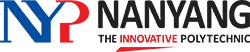

# IT2311 Assignment - Task 1b: Topic Modelling

Complete the following sub-tasks:
1.	**Load Data**: Load the clean dataset
2.	**Data Preparation**: Prepares the text representation for this task
3.	**Modelling**: Perform topic modelling and identify the suitable topic number
4.	**Evaluation**: Evaluates the results and identify the topic

For each sub-task, perform the necessary steps and **explain the rationale taken for each step in the Jupyter notebook**. 

**Done by: Wong Kang Bin 244423Q**

## Import libraries and download the packages

In [1]:
import pandas as pd
import nltk
from nltk.probability import FreqDist #Used for word frequency distribution
from nltk.tokenize import word_tokenize 
import string
import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer


import gensim
from gensim import corpora
from gensim.models import CoherenceModel

[nltk_data] Downloading package stopwords to C:\Users\Kang
[nltk_data]     Bin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Kang
[nltk_data]     Bin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Load Data

In [2]:
task1b_df_wb = pd.read_json('TMSA_Assignemt_Task1_CleanedData.json', orient='records', lines=True)
task1b_df_wb.head()

,project_id,document_text,document_type
0,P170640,world bank public information awareness servic...,APPROVAL
1,P007810,document world bank official only report proje...,APPROVAL
2,P002034,document file copy world bank official only re...,APPROVAL
3,P003542,document world bank official only report imple...,REVIEW
4,P109683,independent evaluation group implementation co...,REVIEW


## Data Exploration 


We will be using the frequency distribution plot and the topics distribution to see if there are any additional words that should be removed apart from the common preprocessing techniques like removing stop words and lemmatization.

<Axes: xlabel='Samples', ylabel='Counts'>

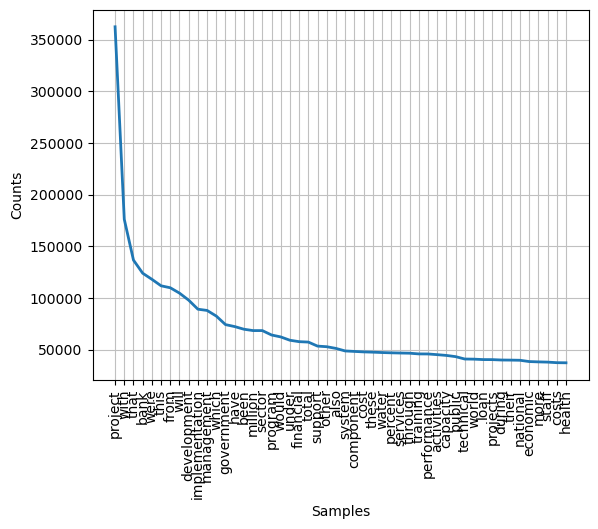

In [3]:
# Generate frequency distribution plot
all_words = [word.lower() for sent in task1b_df_wb.document_text for word in word_tokenize(sent)]
freq_dist = nltk.FreqDist(all_words)

# plot the frequency distribution of the top 50 words
freq_dist.plot(50, cumulative=False)


As mentioned from task 1a which is the data preparation step, domain-specific terms like 'World Bank Project' are dominant. As shown the frequency distribution plot, the entire domain-specific terms appeared. Thus, 'World Bank Project' should be removed

We can also remove words that describe the process of a world bank project and retain words they might represent possible topics for the model to find. Additonal grammmatical words like 'would' and "also" will also be removed. But this distribution alone may not be sufficient enough in determining the list of words to remove. We can also use the LDA modelling technique to identify the distribution of the words in each topic since it can be used as a feature selection technique. For this case, we will use the LDA modelling technique to generate 5 sample topics to gather insights on the topic-words distribution.

Topic Modelling on Raw Data using LDA Model for exploration purposes

In [ ]:
# Get bag of words from corpus
corpus_text = task1b_df_wb['document_text'].values.tolist()

# Retrieve first 5 rows of tokenized text
corpus_text[:5]


['world bank public information awareness services vulnerable communities project information document identification concept stage public disclosure copy concept stage date prepared updated report pidc page world bank public information awareness services vulnerable communities basic information basic project data environmental project parent project social risk project name classification moderate public information awareness services vulnerable communities region country date prepared estimated date approval people democratic east asia pacific republic public disclosure copy financing instrument borrower implementing agency investment project helvetas swiss helvetas swiss financing intercooperation intercooperation project financing data millions summary newfin total project cost total financing financing details newfinenh world bank group financing trust funds japan social development fund introduction context country context with thirds population living rural areas peoples democr

The above output produced a list of sentences. To allow the LDA model to work, we need to further tokenize them into words by performing the split function

In [7]:

tokenized_corpus = [doc.split() for doc in corpus_text] 

dictionary = corpora.Dictionary(tokenized_corpus)
doc_term_matrix = [dictionary.doc2bow(doc) for doc in tokenized_corpus]

In [ ]:
# Using LDA to discover the distribution of words used in 5 generated sample topics

from pprint import pprint
# Identify the topic
topic_num = 5
word_num = 20

Lda = gensim.models.ldamodel.LdaModel
ldamodel = Lda(doc_term_matrix, num_topics = topic_num, id2word = dictionary, passes=5)

pprint(ldamodel.print_topics(num_topics=topic_num, num_words=word_num))

[(0,
  '0.012*"pour" + 0.010*"projet" + 0.010*"dans" + 0.004*"total" + 0.004*"para" '
  '+ 0.004*"sont" + 0.003*"plus" + 0.003*"avec" + 0.003*"services" + '
  '0.003*"proyecto" + 0.002*"sera" + 0.002*"millions" + 0.002*"gestion" + '
  '0.002*"entre" + 0.002*"dollars" + 0.002*"banque" + 0.002*"project" + '
  '0.002*"production" + 0.002*"programme" + 0.002*"cette"'),
 (1,
  '0.015*"project" + 0.011*"would" + 0.008*"with" + 0.007*"from" + '
  '0.007*"total" + 0.006*"million" + 0.006*"which" + 0.006*"water" + '
  '0.006*"that" + 0.005*"this" + 0.005*"about" + 0.005*"will" + 0.005*"been" + '
  '0.005*"bank" + 0.005*"development" + 0.004*"have" + 0.004*"cost" + '
  '0.004*"year" + 0.004*"production" + 0.004*"loan"'),
 (2,
  '0.019*"project" + 0.013*"will" + 0.010*"with" + 0.007*"that" + '
  '0.007*"management" + 0.007*"bank" + 0.006*"development" + 0.006*"from" + '
  '0.006*"this" + 0.005*"implementation" + 0.005*"support" + 0.004*"world" + '
  '0.004*"activities" + 0.004*"sector" + 0.004*"w

Based on the topic distribution, it reveals the presence of foriegn words, more specifically on French and Spainish which creates noise to the data. Thus, we will remove words that are foriegn. Evidently, bank and project needs to be removed as they occupy most of the topic distribution. Stop words can be seen in the topic distribution which will subsequenly be removed as well.

## Data Preparation




In [9]:
# (1) Removing stop words
stop = set(stopwords.words('english'))
# Words added to stop words list
domain_stop = ["project", "bank", "world", "would", "also", "management", "implementation", "development"]
stop.update(domain_stop)

# (2) Normalise the words
lemma = WordNetLemmatizer()

def preprocess_text(text):
    
    # 1. Remove stop words
    stop_free = ' '.join([i for i in text.split() if i not in stop]) 

    # 2. Normalize the words
    normalized = ' '.join(lemma.lemmatize(word) for word in stop_free.split())
    return normalized

    

# Apply the preprocessing function to raw data
task1b_df_wb['document_text'] = task1b_df_wb['document_text'].apply(lambda x: preprocess_text(x))
task1b_df_wb.head()

,project_id,document_text,document_type
0,P170640,public information awareness service vulnerabl...,APPROVAL
1,P007810,document official report completion report pan...,APPROVAL
2,P002034,document file copy official report report reco...,APPROVAL
3,P003542,document official report completion report chi...,REVIEW
4,P109683,independent evaluation group completion report...,REVIEW


In [10]:
# Download the words corpus package
nltk.download('words')

[nltk_data] Downloading package words to C:\Users\Kang
[nltk_data]     Bin\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


True

In [11]:
# Get all english vocabulary from the NLTK word corpus library
english_vocab = set(w.lower() for w in nltk.corpus.words.words())

def remove_foriegn_words(text):
    # Only keep words that are in the English vocabulary 
    cleaned = [w for w in text.split() if w.lower() in english_vocab]
    return " ".join(cleaned)

# Apply to your text column
task1b_df_wb['document_text'] = task1b_df_wb['document_text'].apply(remove_foriegn_words)

In [12]:
# Get bag of words from corpus which will be used as features
corpus_text = task1b_df_wb['document_text'].values.tolist()

# Retrieve first 5 rows of tokenized text
corpus_text[:5]


['public information awareness service vulnerable community information document identification concept stage public disclosure copy concept stage date prepared report page public information awareness service vulnerable community basic information basic data environmental parent social risk name classification moderate public information awareness service vulnerable community region country date prepared date approval people democratic east pacific republic public disclosure copy instrument borrower agency investment swiss swiss data million summary total cost total detail group trust fund japan social fund introduction context country context third population living rural area people democratic republic agrarian economy population density classified lower middle income country since country experienced average economic growth rate percent although tapered recent year percent growth rate percent rate growth primarily driven mining sector however contribution growth page public informa

In [13]:

# Tokenize the documents into words
tokenized_corpus = [doc.split() for doc in corpus_text] 

# Filter out words that occurs in less than 20 documents, or more than 40% of the documents for better accuracy.
# Main purpose of filtering the dictionary is to ensure that every topics that is generated are unique.
dictionary.filter_extremes(no_below=20, no_above=0.4)
doc_term_matrix = [dictionary.doc2bow(doc) for doc in tokenized_corpus]

## Modelling




The LDA model will be used to generate the required topics we need. However, we are unsure how many topics do we exactly need. Hence, using the coherence and perplexity metric can help solve this issue. An optimal number of topics will be determined based on how low the perplexity value is and how high the coherence value is.

In [14]:
def compute_metrics(dictionary, corpus, texts, limit, start=2, step=2):
    coherence_values = []
    perplexity_values = []
    model_list = []
    for num_topics in range(start, limit, step):
        model= gensim.models.ldamodel.LdaModel(corpus=corpus, num_topics = num_topics, id2word = dictionary, passes=5)
        model_list.append(model)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())
        perplexity_values.append(model.log_perplexity(corpus))

    return model_list, coherence_values, perplexity_values

In [15]:

# Execute the metrics evaluation function
model_list, coherence_values, perplexity_values = compute_metrics(dictionary=dictionary, corpus=doc_term_matrix,
                                                        texts=tokenized_corpus,
                                                        start=2, limit=11, step=1
                                                        )

## Evaluation




Evaluations Metrics Comparison based on the number of topics

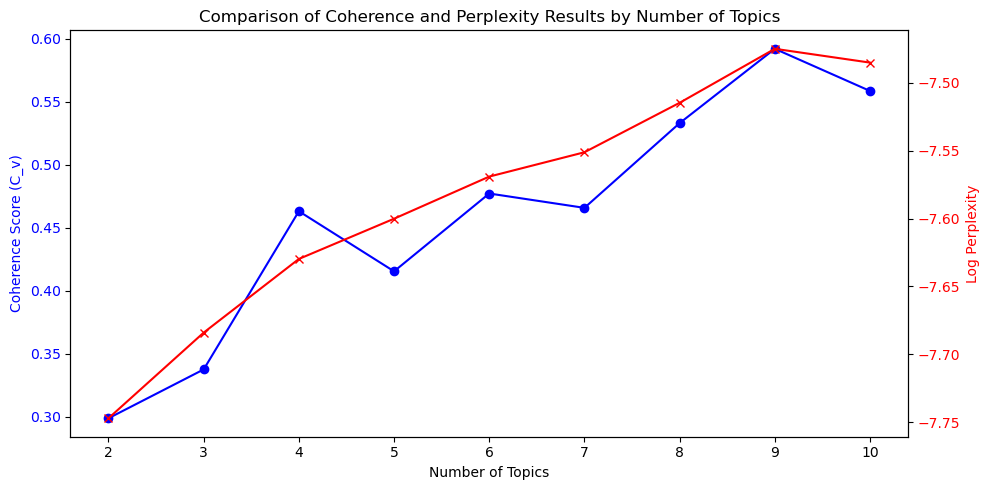

In [ ]:
start, limit, step = 2, 11, 1
fig, ax1 = plt.subplots(figsize=(10, 5))

# x-axis: number of topics, y-axis: coherence and perplexity results
x = range(start, limit, step)

# Plot Coherence on the left Y-axis
ax1.set_xlabel('Number of Topics')
ax1.set_ylabel('Coherence Score (C_v)', color='blue')
ax1.plot(x, coherence_values, color='blue', marker='o', label='Coherence')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second Y-axis for Perplexity
ax2 = ax1.twinx() 
ax2.set_ylabel('Log Perplexity', color='red')
ax2.plot(x, perplexity_values, color='red', marker='x', label='Perplexity')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Comparison of Coherence and Perplexity Results by Number of Topics')
fig.tight_layout()
plt.show()

To determine the optimal topic number(k), I used the dual-metric selection approach where it is determined based on low perplexity and high coherence value. Based on the above chart, we can see that the rise in perplexity score becomes gentler at k=4 while the coherence reached an optimal peak. Hence, this balance helps to ensure that the resulting 4 topics are both statiscally and semantically meaningful in categorizing the World Bank Projects.

In [ ]:
# Print the coherence and perplexity scores
for m, cv, pv in zip(x, coherence_values, perplexity_values):
    print("Num Topics =", m, " has Coherence Value of", round(cv, 4))
    print("Num Topics =", m, " has Perplexity Value of", round(pv, 4))



Num Topics = 2  has Coherence Value of 0.2987
Num Topics = 2  has Perplexity Value of -7.7472
Num Topics = 3  has Coherence Value of 0.3375
Num Topics = 3  has Perplexity Value of -7.6841
Num Topics = 4  has Coherence Value of 0.463
Num Topics = 4  has Perplexity Value of -7.6298
Num Topics = 5  has Coherence Value of 0.4153
Num Topics = 5  has Perplexity Value of -7.6001
Num Topics = 6  has Coherence Value of 0.4771
Num Topics = 6  has Perplexity Value of -7.5691
Num Topics = 7  has Coherence Value of 0.4657
Num Topics = 7  has Perplexity Value of -7.5511
Num Topics = 8  has Coherence Value of 0.533
Num Topics = 8  has Perplexity Value of -7.5147
Num Topics = 9  has Coherence Value of 0.592
Num Topics = 9  has Perplexity Value of -7.4749
Num Topics = 10  has Coherence Value of 0.5585
Num Topics = 10  has Perplexity Value of -7.4851


In [ ]:
from pprint import pprint
# Identify the topic
topic_num = 4
word_num = 20

Lda = gensim.models.ldamodel.LdaModel
ldamodel = Lda(doc_term_matrix, num_topics = topic_num, id2word = dictionary, passes=5)
# Number of passess is based on the number of times it takes for the model to train the entire corpus
# More passes increases computation time and improve model.
# Thus, 5 passes is used to help provide a solid balance between obtaining high-quality topics and maintaing fast execution

pprint(ldamodel.print_topics(num_topics=topic_num, num_words=word_num))

[(0,
  '0.017*"road" + 0.009*"para" + 0.006*"plant" + 0.005*"farmer" + '
  '0.005*"irrigation" + 0.005*"company" + 0.005*"energy" + 0.005*"traffic" + '
  '0.004*"farm" + 0.004*"facility" + 0.004*"condition" + 0.004*"export" + '
  '0.004*"debt" + 0.004*"tariff" + 0.004*"crop" + 0.004*"electricity" + '
  '0.003*"port" + 0.003*"asset" + 0.003*"station" + 0.003*"revenue"'),
 (1,
  '0.030*"pour" + 0.020*"forest" + 0.010*"conservation" + 0.009*"forestry" + '
  '0.008*"plus" + 0.007*"dollar" + 0.007*"zone" + 0.006*"plantation" + '
  '0.006*"technique" + 0.006*"gestion" + 0.005*"formation" + 0.005*"rapport" + '
  '0.005*"statistical" + 0.004*"mise" + 0.004*"senegal" + 0.004*"ecosystem" + '
  '0.004*"exploitation" + 0.004*"environ" + 0.004*"route" + 0.004*"etude"'),
 (2,
  '0.015*"indicator" + 0.007*"beneficiary" + 0.005*"moderately" + '
  '0.005*"household" + 0.005*"comment" + 0.004*"district" + '
  '0.004*"stakeholder" + 0.004*"procedure" + 0.004*"arrangement" + '
  '0.004*"facility" + 0.004*

In [ ]:
# Visualise the topic
import pyLDAvis
import pyLDAvis.gensim_models
import matplotlib.pyplot as plt
%matplotlib inline

# visualize the topics and keywords
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(ldamodel, doc_term_matrix, dictionary)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2     -0.037579  0.028610       1        1  41.052032
0     -0.020903 -0.119585       2        1  39.119471
3     -0.109517  0.060207       3        1  12.363945
1      0.167998  0.030769       4        1   7.464551, topic_info=           Term          Freq         Total Category  logprob  loglift
1816     school  25167.000000  25167.000000  Default  30.0000  30.0000
1671       pour  11066.000000  11066.000000  Default  29.0000  29.0000
1900    teacher  10682.000000  10682.000000  Default  28.0000  28.0000
133      forest   9260.000000   9260.000000  Default  27.0000  27.0000
904        road  34548.000000  34548.000000  Default  26.0000  26.0000
...         ...           ...           ...      ...      ...      ...
999       trade   1248.107874   5726.831243   Topic4  -5.6716   1.0715
933        site   1300.293299  11291.472932   Topic4  -5.6307   0.4335
327     village   1263.164140   8401.304171   Topic4  -5.6596   0.7002
1488  indicator   1401.490608  38826.542597   Topic4  -5.5557  -0.7266
470   condition   1280.083655  16147.209639   Topic4  -5.6463   0.0602

[338 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
2448      1  0.116395  academic
2448      2  0.024174  academic
2448      3  0.818345  academic
2448      4  0.041186  academic
7006      1  0.017225  agricole
...     ...       ...       ...
9526      4  0.003471      wool
1049      1  0.188987      zone
1049      2  0.305860      zone
1049      3  0.014920      zone
1049      4  0.490495      zone

[1059 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 1, 4, 2])

Topics Intepretation:
1. Topic 1: Social Service Project Management

    Reason: Covers high frequency administrative and evaluated terms like 'Indicators' and 'Procedures' along with the specific sector on social service as evident by 'emergency', 'care' and 'donor'. It has a slight overlap with Topic 3, Education where students and teachers can contribute to society by performing various social services activites that builds community service skills.

2. Topic 2: Energy Infrastructure and Finances

    Reason: Strong presence of different energy resources ("Electricity", "Plant", "industrial") alongside with financial metrics ("Tarriff", "Revenue", "Asset", "sale") which combines both sub-topics (Energy and Finances) into a main topic.

3. Topic 3: Education

    Reason: This topic is driven by the high presence of the education related words hierachy ranging from "school", "teachers" and "students" to the "ciriculum" and "university". 


4. Topic 4: Environmental Conservation and Foresty Management

    Reason: Words such as 'pour', 'forest', 'conservation' and 'foresty' are the key words found in this topic as it represents ecological terms




## References
1. Jordan, Luke S. (2021). World Bank Project Documents [Dataset]. Hugging Face. 
Available at: https://huggingface.co/datasets/lukesjordan/worldbank-project-documents  
2. Barthelemy. (2021, October 12). How to check if a word is an English word with Python? Stack Overflow. https://stackoverflow.com/questions/3788870/how-to-check-if-a-word-is-an-english-word-with-python
3. Gensim: topic modelling for humans. (n.d.). https://radimrehurek.com/gensim/auto_examples/tutorials/run_lda.html
4. Lecture 7 Notes on Topic Modelling
5. P7b Topic Modelling Solution
6. Prabhakaran, S. (2022, April 28). Gensim Topic Modeling - A Guide to Building Best LDA models. MachineLearningPlus. https://machinelearningplus.com/nlp/topic-modeling-gensim-python/
7. Bot verification. (n.d.). https://pythonguides.com/matplotlib-two-y-axes/